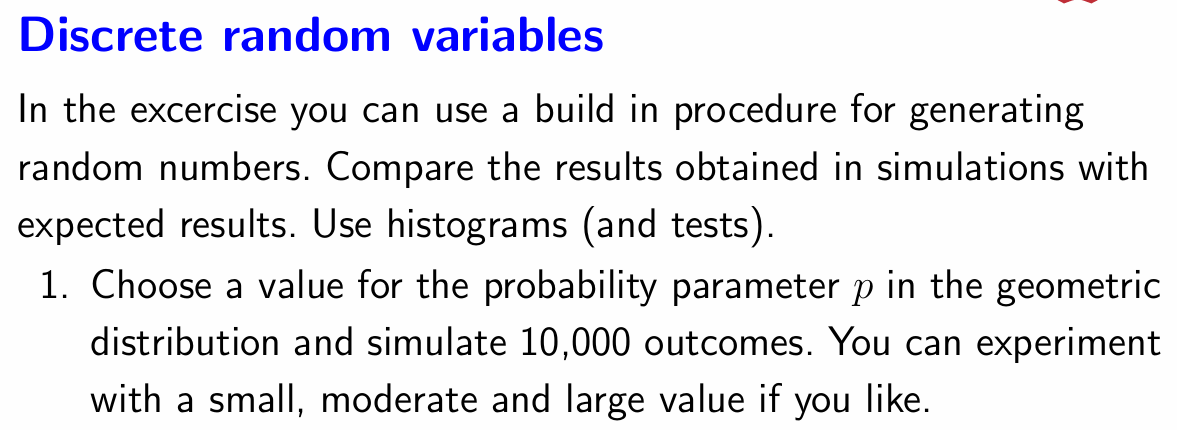

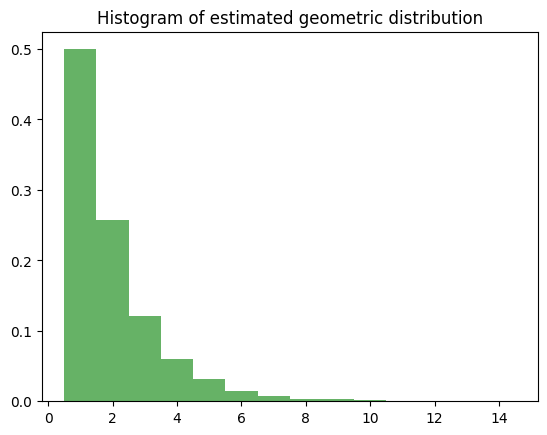

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
U = []
N = 10000
p = 0.5
for _ in range(0, N-1):
    U.append(random.random())

X = []
for u in U:
    X.append(np.floor((np.log(u)/np.log(1-p))) + 1)

plt.hist(X, bins=np.arange(1, max(X)+1)-0.5, density=True, alpha=0.6, color='g')
plt.title("Histogram of estimated geometric distribution")
plt.show()


Chi-square (estimated vs Geometric(p=0.5))
Statistic = 4.6722, df = 6, p-value = 0.586489


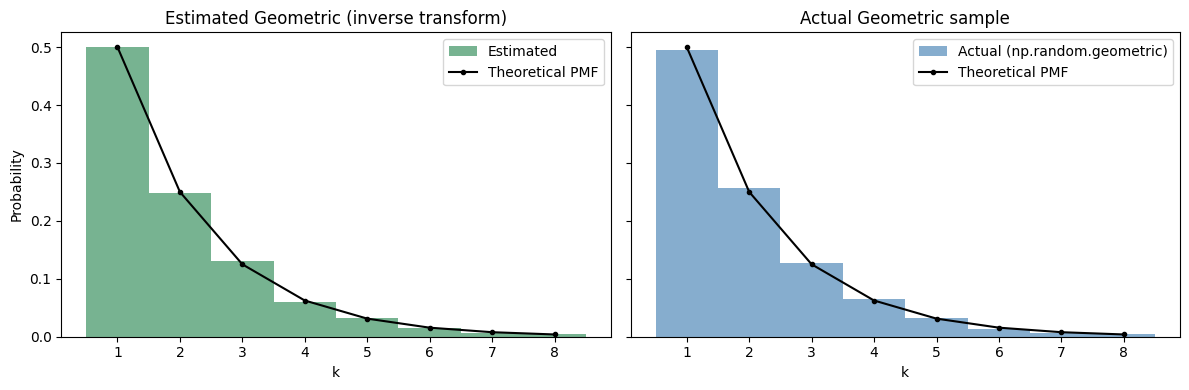

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, geom

# Setup
N = 10000
p = 0.5
rng = np.random.default_rng(42)

# Estimated sample via inverse transform
U = rng.random(N)
U = np.clip(U, 1e-12, 1 - 1e-12)  # avoid log(0)
X_est = (np.floor(np.log(U) / np.log(1 - p)) + 1).astype(int)

# "Actual" sample from built-in geometric generator
X_true = rng.geometric(p, size=N)

# ---- Chi-square GOF test for estimated sample vs theoretical Geometric(p) ----
# Use tail grouping so expected counts are not tiny
k_max = int(np.ceil(np.quantile(X_est, 0.99)))  # last bin is tail >= k_max
bins = np.arange(1, k_max)

obs_main = np.array([(X_est == k).sum() for k in bins], dtype=float)
obs_tail = (X_est >= k_max).sum()
obs = np.append(obs_main, obs_tail)

prob_main = geom.pmf(bins, p)
prob_tail = geom.sf(k_max - 1, p)  # P(X >= k_max)
probs = np.append(prob_main, prob_tail)

exp = N * probs

chi2_stat = np.sum((obs - exp) ** 2 / exp)
df = len(obs) - 1  # no parameter estimated from data
p_value = 1 - chi2.cdf(chi2_stat, df)

print(f"Chi-square (estimated vs Geometric(p={p}))")
print(f"Statistic = {chi2_stat:.4f}, df = {df}, p-value = {p_value:.6g}")

# ---- Side-by-side histograms ----
max_x = int(np.quantile(np.concatenate([X_est, X_true]), 0.995))
x_vals = np.arange(1, max_x + 1)
pmf_vals = geom.pmf(x_vals, p)

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Estimated
ax[0].hist(X_est, bins=np.arange(1, max_x + 2) - 0.5, density=True, alpha=0.65, color='seagreen', label='Estimated')
ax[0].plot(x_vals, pmf_vals, 'ko-', ms=3, lw=1.5, label='Theoretical PMF')
ax[0].set_title("Estimated Geometric (inverse transform)")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Probability")
ax[0].legend()

# Actual (numpy geometric)
ax[1].hist(X_true, bins=np.arange(1, max_x + 2) - 0.5, density=True, alpha=0.65, color='steelblue', label='Actual (np.random.geometric)')
ax[1].plot(x_vals, pmf_vals, 'ko-', ms=3, lw=1.5, label='Theoretical PMF')
ax[1].set_title("Actual Geometric sample")
ax[1].set_xlabel("k")
ax[1].legend()

plt.tight_layout()
plt.show()

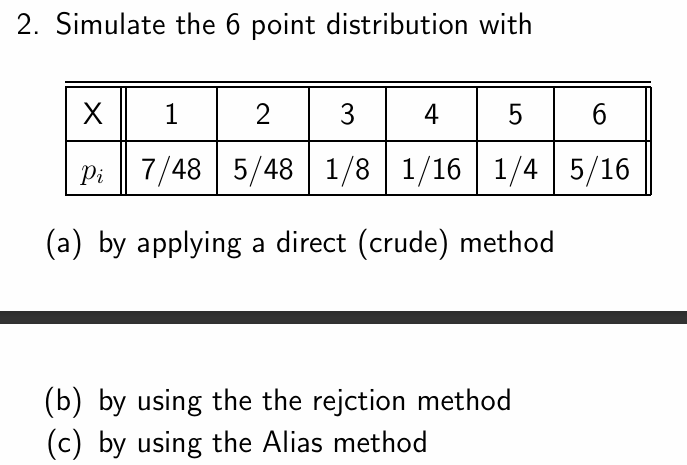

In [65]:
X = [1,2,3,4,5,6]
p = [7/48, 5/48, 1/8, 1/16, 1/4, 5/16]

U = []
N = 10000
for _ in range(0, N-1):
    U.append(random.random())

# (a) direct (crude) method.
def crude_method(p, U, n):
    cum_p = np.cumsum([0] + list(p))
    X = []
    for u in U:
        for i in range(1, n+1):
            if cum_p[i-1] < u <= cum_p[i]:
                X.append(i)
                break
    return np.array(X)


X_crude = crude_method(p, U, len(p))

# (b) Rejection method
def rejection_method(p, U, n, c):
    X = []
    i = 0
    while i < len(U) - 1:
        u1 = U[i]
        i += 1
        I = int(np.floor(u1 * n))
        
        u2 = U[i]
        i += 1
        
        if u2 <= p[I] / c:
            X.append(I + 1)
    return np.array(X)

c = max(p) * len(p)
X_rejection = rejection_method(p, U, len(p), c)

# (c) Alias method
def alias_method(p, U, n, eps=1e-10):
    F = n * np.array(p)
    L = np.zeros(n, dtype=int)
    S = []
    G = []
    
    for i in range(n):
        if F[i] < 1 - eps:
            S.append(i)
        else:
            G.append(i)
    
    while len(S) > 0 and len(G) > 0:
        i = S.pop(0)
        j = G[0]
        
        L[i] = j 
        F[j] = F[j] - (1 - F[i])
        
        if F[j] < 1 - eps:
            G.pop(0)
            S.append(j)

    X = []
    i = 0
    while i < len(U) - 1:
        u1 = U[i]
        i += 1
        u2 = U[i]
        i += 1
        I = int(np.floor(u1 * n))
        
        if u2 <= F[I]:
            X.append(I + 1)
        else:
            X.append(L[I] + 1)
    
    return X

X_alias = alias_method(p, U, len(p))

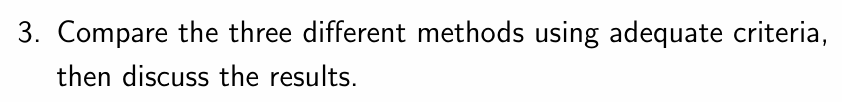

Aside from just visual comparison we will also perform a chi-square test for each of the estimated distributions to compare them with the actual distribution. 


Crude Method:
  Observed: [1479  986 1223  628 2560 3123]
  Expected: [1458 1041 1249  624 2499 3124]
  Chi-square statistic: 5.3070
  Degrees of freedom: 5
  P-value: 0.3796
  Critical value (α=0.05): 11.0705
  PASS (fail to reject H0 at α=0.05)

Rejection Method:
  Observed: [ 67  54  53  36  93 142]
  Expected: [ 64  46  55  27 111 139]
  Chi-square statistic: 6.9194
  Degrees of freedom: 5
  P-value: 0.2267
  Critical value (α=0.05): 11.0705
  PASS (fail to reject H0 at α=0.05)

Alias Method:
  Observed: [ 745  471  671  336 1202 1574]
  Expected: [ 729  520  624  312 1249 1562]
  Chi-square statistic: 12.1947
  Degrees of freedom: 5
  P-value: 0.0322
  Critical value (α=0.05): 11.0705
  FAIL (fail to reject H0 at α=0.05)


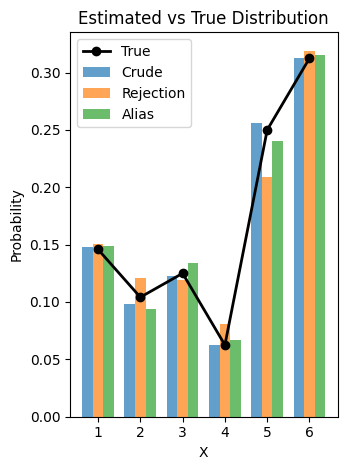


Sample sizes: Crude=9999, Rejection=445, Alias=4999


In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import random

# Setup
X_vals = np.array([1, 2, 3, 4, 5, 6])
p = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])
n = len(p)
N = 10000

np.random.seed(42)
U = np.random.random(N)

def chi_square_test(X, p, N, method_name):
    observed = np.bincount(X, minlength=n+1)[1:]
    expected = N * np.array(p)
    
    print(f"\n{method_name}:")
    print(f"  Observed: {observed}")
    print(f"  Expected: {expected.astype(int)}")
    
    chi2_stat = np.sum((observed - expected)**2 / expected)
    df = n - 1
    p_value = 1 - stats.chi2.cdf(chi2_stat, df)
    
    print(f"  Chi-square statistic: {chi2_stat:.4f}")
    print(f"  Degrees of freedom: {df}")
    print(f"  P-value: {p_value:.4f}")
    
    crit = stats.chi2.ppf(0.95, df)
    print(f"  Critical value (α=0.05): {crit:.4f}")
    print(f"  {'PASS' if chi2_stat < crit else 'FAIL'} (fail to reject H0 at α=0.05)")
    
    return chi2_stat, p_value

# Run tests
chi_square_test(X_crude, p, len(X_crude), "Crude Method")
chi_square_test(X_rejection, p, len(X_rejection), "Rejection Method")
chi_square_test(X_alias, p, len(X_alias), "Alias Method")

# --- Visualization ---
plt.subplot(1, 2, 2)
x = np.arange(1, n+1)
width = 0.25

# Normalize histograms to probabilities for comparison
def normalize_counts(X, n):
    counts = np.bincount(X, minlength=n+1)[1:]
    return counts / len(X)

plt.bar(x - width, normalize_counts(X_crude, n), width, label='Crude', alpha=0.7)
plt.bar(x, normalize_counts(X_rejection, n), width, label='Rejection', alpha=0.7)
plt.bar(x + width, normalize_counts(X_alias, n), width, label='Alias', alpha=0.7)
plt.plot(x, p, 'ko-', label='True', linewidth=2)
plt.title("Estimated vs True Distribution")
plt.xlabel("X")
plt.ylabel("Probability")
plt.xticks(x)
plt.legend()

plt.tight_layout()
plt.show()

# --- Sample sizes ---
print(f"\nSample sizes: Crude={len(X_crude)}, Rejection={len(X_rejection)}, Alias={len(X_alias)}")

```latex
\begin{table}[h]
\centering
\begin{tabular}{lrrrr}
\hline
Method & Chi-square statistic & Degrees of freedom & P-value & Critical value ($\alpha=0.05$) \\
\hline
Crude Method & 5.3070 & 5 & 0.3796 & 11.0705 \\
Rejection Method & 6.9194 & 5 & 0.2267 & 11.0705 \\
Alias Method & 12.1947 & 5 & 0.0322 & 11.0705 \\
\hline
\end{tabular}
\caption{Chi-square goodness-of-fit test summary}
\label{tab:chi_square_summary}
\end{table}
```

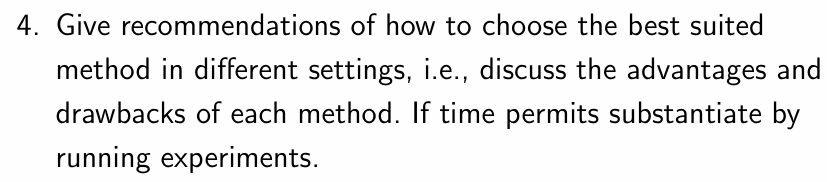

### Crude method
The crude method is by far the simplest of the three to understand and implement and can also be implemented quite efficiently allowing for fast estimations of different distributions. However, given that it uses the randomly generated values directly, it does pose the risk of these values being quite far off and it would require generating many random values to secure a suitable estimation. 

The method seems best suited for when we have alot of values for the distribution we wish to estimate and we need to estimate it quickly without huge concerns for accuracy.

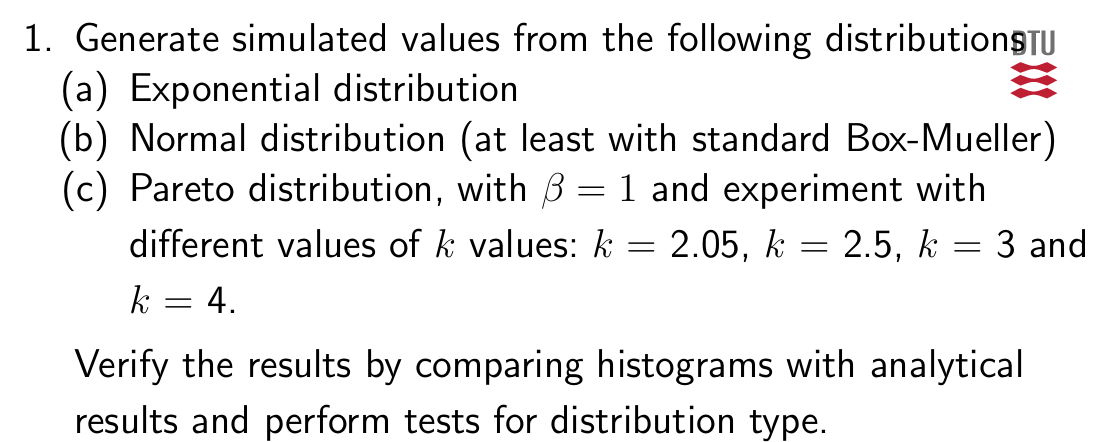

KS test for Exponential: D=0.0074, p-value=0.6343


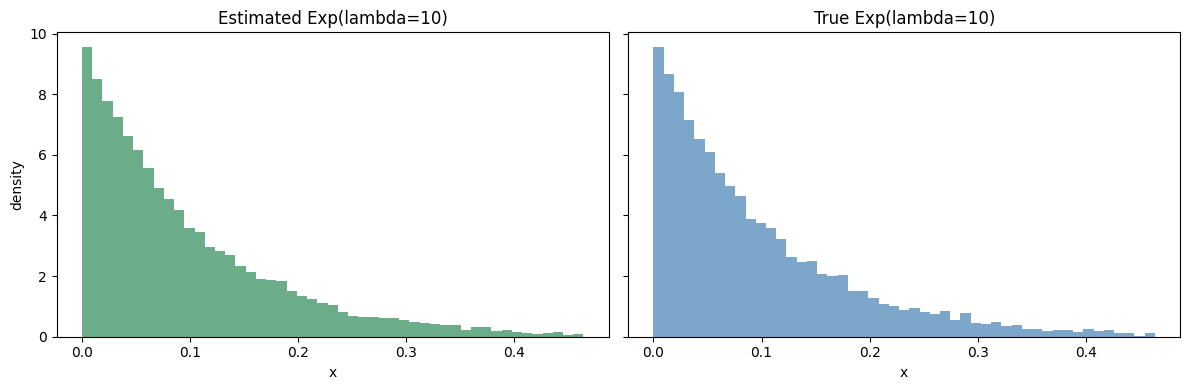

KS test for Standard Normal: D=0.0115, p-value=0.1423


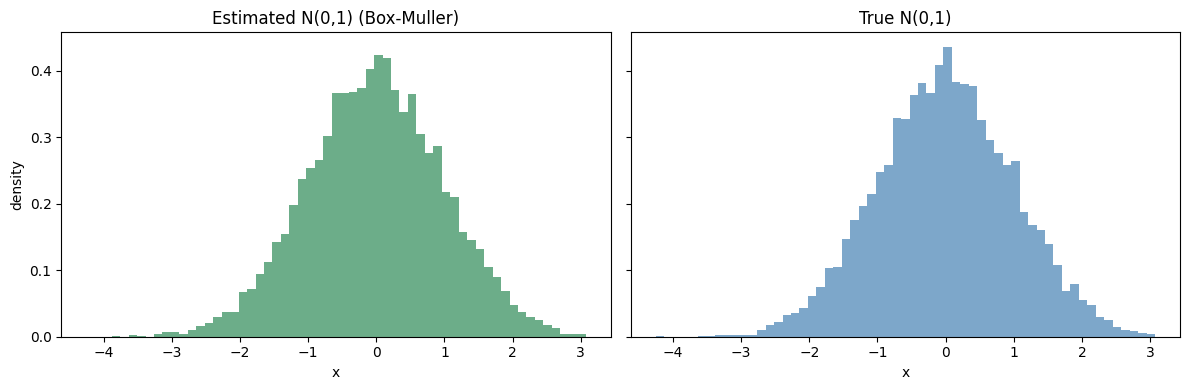

KS test for Pareto(k=2.05, beta=1): D=0.0050, p-value=0.9634


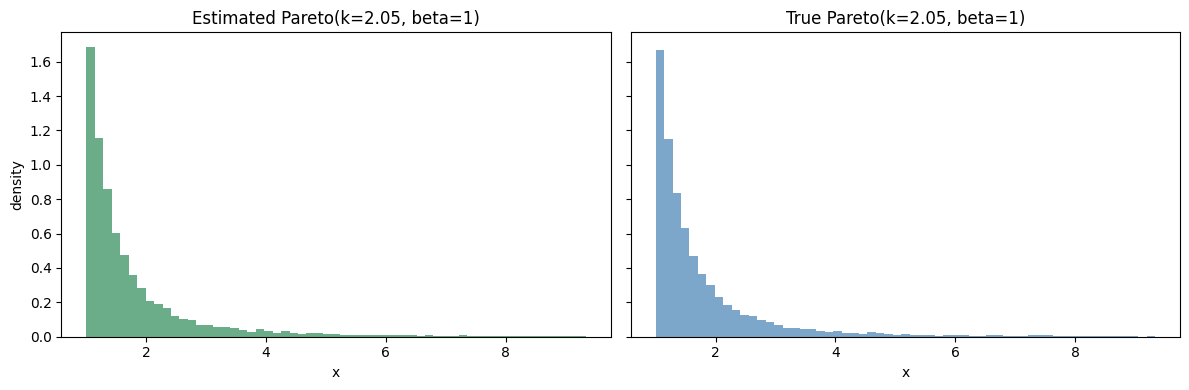

KS test for Pareto(k=2.5, beta=1): D=0.0079, p-value=0.5521


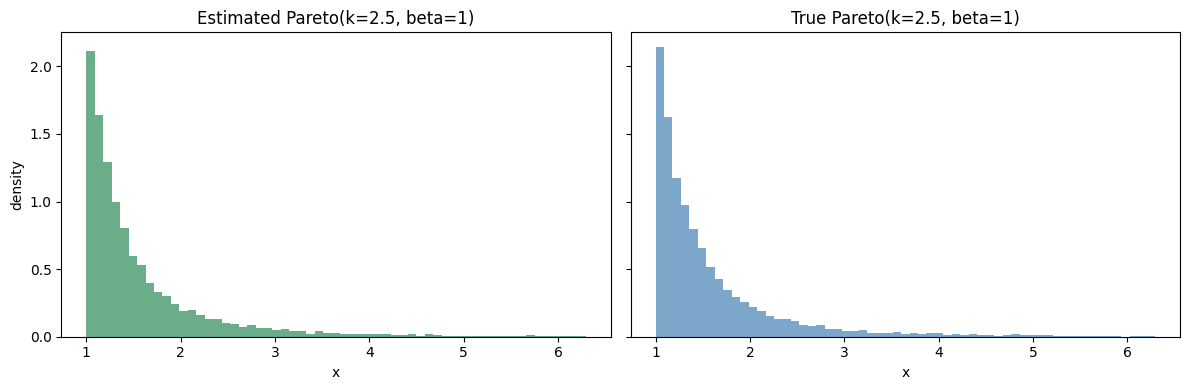

KS test for Pareto(k=3, beta=1): D=0.0090, p-value=0.3876


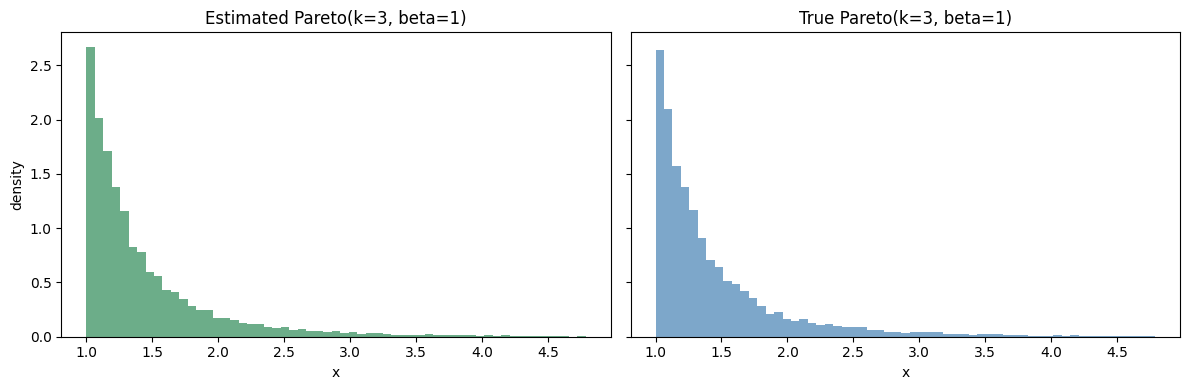

KS test for Pareto(k=4, beta=1): D=0.0073, p-value=0.6526


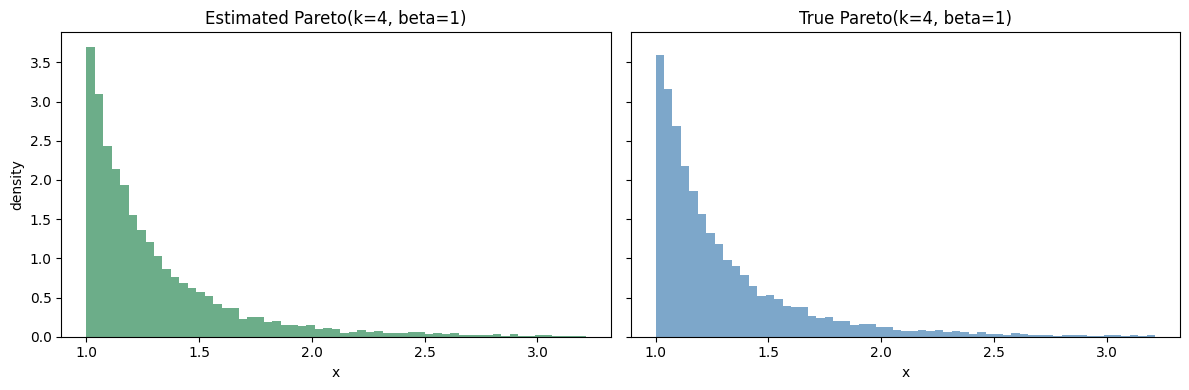

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

rng = np.random.default_rng(42)
N = 10000

def side_by_side_hist(x_est, x_true, title_est, title_true, bins=50, q=0.99):
    # Use common bins and trim at a high quantile to keep heavy tails readable
    xmax = np.quantile(np.concatenate([x_est, x_true]), q)
    xmin = min(np.min(x_est), np.min(x_true))
    common_bins = np.linspace(xmin, xmax, bins)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    ax[0].hist(x_est, bins=common_bins, density=True, alpha=0.7, color="seagreen")
    ax[0].set_title(title_est)
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("density")

    ax[1].hist(x_true, bins=common_bins, density=True, alpha=0.7, color="steelblue")
    ax[1].set_title(title_true)
    ax[1].set_xlabel("x")

    plt.tight_layout()
    plt.show()

# (a) Exponential: estimated vs true
lam = 10
U = rng.random(N)
X_est_exp = -np.log(U) / lam
X_true_exp = rng.exponential(scale=1/lam, size=N)
D, p_ks = kstest(X_est_exp, 'expon', args=(0, 1/lam))
print(f"KS test for Exponential: D={D:.4f}, p-value={p_ks:.4f}")
side_by_side_hist(
    X_est_exp,
    X_true_exp,
    "Estimated Exp(lambda=10)",
    "True Exp(lambda=10)"
)

# (b) Standard normal via Box-Muller: estimated vs true
U1 = rng.random(N // 2)
U2 = rng.random(N // 2)
R = np.sqrt(-2 * np.log(U1))
Theta = 2 * np.pi * U2
Z1 = R * np.cos(Theta)
Z2 = R * np.sin(Theta)
X_est_norm = np.concatenate([Z1, Z2])[:N]
X_true_norm = rng.normal(loc=0, scale=1, size=N)
D, p_ks = kstest(X_est_norm, 'norm', args=(0, 1))
print(f"KS test for Standard Normal: D={D:.4f}, p-value={p_ks:.4f}")    
side_by_side_hist(
    X_est_norm,
    X_true_norm,
    "Estimated N(0,1) (Box-Muller)",
    "True N(0,1)",
    bins=60,
    q=0.999
)

# (c) Pareto(beta=1, k): estimated vs true for each k
k_values = [2.05, 2.5, 3, 4]
beta = 1.0

for k in k_values:
    U = rng.random(N)

    # Type-I Pareto with beta=1 support x >= 1
    X_est_par = beta * (U ** (-1 / k))
    X_true_par = beta * (rng.pareto(k, N) + 1)

    D, p_ks = kstest(X_est_par, 'pareto', args=(k, 0, beta))
    print(f"KS test for Pareto(k={k}, beta=1): D={D:.4f}, p-value={p_ks:.4f}")

    side_by_side_hist(
        X_est_par,
        X_true_par,
        f"Estimated Pareto(k={k}, beta=1)",
        f"True Pareto(k={k}, beta=1)",
        bins=60,
        q=0.99
    )

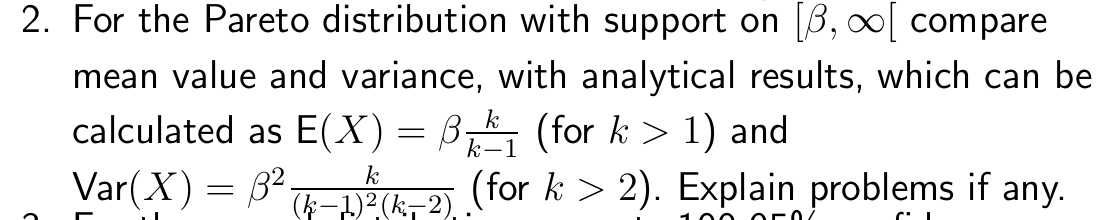

In [ ]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
N = 10000
beta = 1.0
k_values = [2.05, 2.5, 3, 4]

rows = []

for k in k_values:
    U = rng.random(N)
    X = beta * (U ** (-1 / k))

    sample_mean = np.mean(X)
    sample_var = np.var(X, ddof=1)

    theo_mean = beta * k / (k - 1) if k > 1 else np.inf
    theo_var = (beta**2) * k / (((k - 1)**2) * (k - 2)) if k > 2 else np.inf

    rows.append({
        "k": k,
        "sample_mean": sample_mean,
        "theoretical_mean": theo_mean,
        "sample_variance": sample_var,
        "theoretical_variance": theo_var
    })

df = pd.DataFrame(rows)

# Helpful relative errors (skip inf safely)
df["mean_rel_error_%"] = 100 * np.abs(df["sample_mean"] - df["theoretical_mean"]) / df["theoretical_mean"]
df["var_rel_error_%"] = 100 * np.abs(df["sample_variance"] - df["theoretical_variance"]) / df["theoretical_variance"]

print(df.to_string(index=False, float_format=lambda x: f"{x:,.4f}"))

     k  sample_mean  theoretical_mean  sample_variance  theoretical_variance  mean_rel_error_%  var_rel_error_%
2.0500       1.9409            1.9524           4.1515               37.1882            0.5862          88.8365
2.5000       1.6853            1.6667           3.2601                2.2222            1.1193          46.7048
3.0000       1.5042            1.5000           0.8013                0.7500            0.2808           6.8401
4.0000       1.3326            1.3333           0.2205                0.2222            0.0544           0.7580


### Issues
We can see from the results that while the mean is stable for all k, although have a bit larger relative error for small k, the biggest issue is the variance. The relative error for k < 3 are very large in comparison which is because in the formula for the variance, when k is close to 2, the denominator is tiny, so extreme values dominate which the estimation fails to capture.

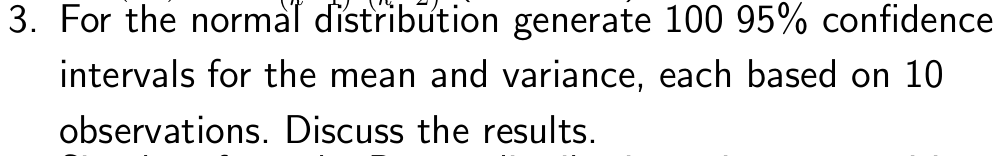

In [2]:
import numpy as np
from scipy.stats import t, chi2

def box_muller_sample(n, rng):
    m = (n + 1) // 2
    u1 = rng.random(m)
    u2 = rng.random(m)

    r = np.sqrt(-2.0 * np.log(u1))
    theta = 2.0 * np.pi * u2

    z1 = r * np.cos(theta)
    z2 = r * np.sin(theta)

    z = np.empty(2 * m)
    z[0::2] = z1
    z[1::2] = z2
    return z[:n]

mu_true = 0.0
sigma_true = 1.0
var_true = sigma_true**2

m = 100
n = 10
alpha = 0.05

rng = np.random.default_rng(42)

mean_cover = []
var_cover = []
var_highs = []
var_lows = []
mean_lows = []
mean_highs = []

for _ in range(m):
    z = box_muller_sample(n, rng)
    x = mu_true + sigma_true * z

    xbar = np.mean(x)
    s2 = np.var(x, ddof=1)
    s = np.sqrt(s2)
    df = n - 1

    # 95% CI for mean
    tcrit = t.ppf(1 - alpha/2, df)
    mean_lo = xbar - tcrit * s / np.sqrt(n)
    mean_hi = xbar + tcrit * s / np.sqrt(n)

    # 95% CI for variance
    chi2_lo = chi2.ppf(alpha/2, df)
    chi2_hi = chi2.ppf(1 - alpha/2, df)
    var_lo = df * s2 / chi2_hi
    var_hi = df * s2 / chi2_lo

    mean_lows.append(mean_lo)
    mean_highs.append(mean_hi)
    var_lows.append(var_lo)
    var_highs.append(var_hi)
    mean_cover.append(mean_lo <= mu_true <= mean_hi)
    var_cover.append(var_lo <= var_true <= var_hi)

mean_cover = np.array(mean_cover)
var_cover = np.array(var_cover)

avg_mean_low = np.mean(mean_lows)
avg_mean_high = np.mean(mean_highs)
avg_var_low = np.mean(var_lows)
avg_var_high = np.mean(var_highs)

print(f"Average mean CI: [{avg_mean_low:.4f}, {avg_mean_high:.4f}]")
print(f"Average variance CI: [{avg_var_low:.4f}, {avg_var_high:.4f}]")

print(f"Mean CI coverage: {mean_cover.sum()}/{m} = {mean_cover.mean():.3f}")
print(f"Variance CI coverage: {var_cover.sum()}/{m} = {var_cover.mean():.3f}")

Average mean CI: [-0.7574, 0.6554]
Average variance CI: [0.4962, 3.4956]
Mean CI coverage: 93/100 = 0.930
Variance CI coverage: 93/100 = 0.930


As we can see in 93\% of the generated confidence intervals, the true value are covered within these intervals for a standard normal distribution.

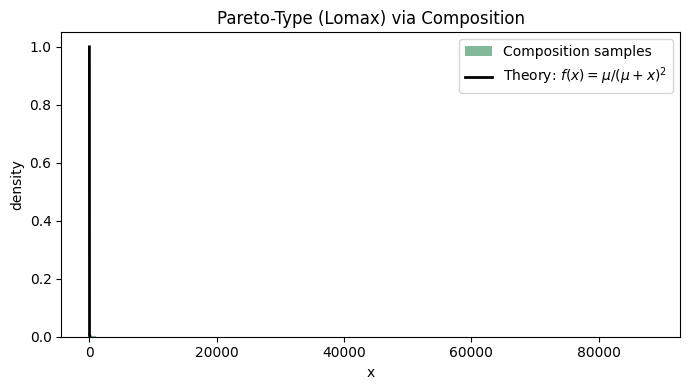

KS test: D=0.0037, p-value=0.1223


In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

rng = np.random.default_rng(42)
N = 100000
mu = 1.0

Y = rng.exponential(scale=1/mu, size=N)

X_comp = rng.exponential(scale=1/Y)

x_grid = np.linspace(0, np.quantile(X_comp, 0.99), 400)
f_theory = mu / (mu + x_grid)**2

plt.figure(figsize=(7,4))
plt.hist(X_comp, bins=80, density=True, alpha=0.6, color="seagreen", label="Composition samples")
plt.plot(x_grid, f_theory, "k-", lw=2, label=r"Theory: $f(x)=\mu/(\mu+x)^2$")
plt.title("Pareto-Type (Lomax) via Composition")
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()
D, p = kstest(X_comp, "lomax", args=(1, 0, mu))
print(f"KS test: D={D:.4f}, p-value={p:.4f}")